In [111]:
from Dataloader import Dataloader
from models import EfficientNet_pretrained
import torch
import torchmetrics
import torch.nn.functional as F
import monai
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [112]:

def load_model(weight_path):
    state = torch.load(weight_path, map_location="cpu")["state_dict"]

    if list(state.keys())[0].startswith('model.'):
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=None
        )
        
        print(state.keys())
        model.load_state_dict(state)
        
    else:
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=weight_path
        )

    model.to(device).eval()
    
    return model

In [113]:
dataloader = Dataloader(path='Files/data_with_splits_dep_disjoint_val_test.csv')
test_dataloader = dataloader(partition='val')

Loading dataset:   0%|          | 0/414 [00:00<?, ?it/s]

Loading dataset: 100%|██████████| 414/414 [03:14<00:00,  2.12it/s]


In [82]:
model_paths_pretrained = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/models/best-model-weights.pth',
]

no_pretrained_path = 'logs/classification/Prostate_BIMCV_no_pretrained/15-Sep-2025-14:51:00/models/best-model-weights.pth'

models_pretrained = [load_model(p) for p in model_paths_pretrained]
no_pretrained_model = load_model(no_pretrained_path)

odict_keys(['model._conv_stem.weight', 'model._bn0.weight', 'model._bn0.bias', 'model._bn0.running_mean', 'model._bn0.running_var', 'model._bn0.num_batches_tracked', 'model._blocks.0.0._depthwise_conv.weight', 'model._blocks.0.0._bn1.weight', 'model._blocks.0.0._bn1.bias', 'model._blocks.0.0._bn1.running_mean', 'model._blocks.0.0._bn1.running_var', 'model._blocks.0.0._bn1.num_batches_tracked', 'model._blocks.0.0._se_reduce.weight', 'model._blocks.0.0._se_reduce.bias', 'model._blocks.0.0._se_expand.weight', 'model._blocks.0.0._se_expand.bias', 'model._blocks.0.0._project_conv.weight', 'model._blocks.0.0._bn2.weight', 'model._blocks.0.0._bn2.bias', 'model._blocks.0.0._bn2.running_mean', 'model._blocks.0.0._bn2.running_var', 'model._blocks.0.0._bn2.num_batches_tracked', 'model._blocks.0.1._depthwise_conv.weight', 'model._blocks.0.1._bn1.weight', 'model._blocks.0.1._bn1.bias', 'model._blocks.0.1._bn1.running_mean', 'model._blocks.0.1._bn1.running_var', 'model._blocks.0.1._bn1.num_batches_t

# Oclussion Sensitivity

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models_pretrained[0]
model.to(device)
model.eval()

occ_sens = monai.visualize.OcclusionSensitivity(nn_module=model, mask_size=8, n_batch=64, verbose=True, mode = 'mean_patch')
idx=np.random.randint(0,len(test_dataloader))

with torch.no_grad():
    img, label = (test_dataloader.dataset[idx]['image'].to(device),test_dataloader.dataset[idx]['label'])
    print(img.shape)
    pred_label = torch.nn.functional.softmax(model(img.unsqueeze(0)), dim=1).argmax().item()
    print(f"Prediction {pred_label}")
    print(f"Label {label.argmax().item()}")
    label = label.argmax().item()
    heatmap = occ_sens(x=img.unsqueeze(0))

norm_heatmap = (heatmap[0][:, 1:2] - heatmap[0][:, 1:2].min()) / (heatmap[0][:, 1:2].max() - heatmap[0][:, 1:2].min())

torch.Size([3, 128, 128, 32])
Prediction 1
Label 1


100%|██████████| 35/35 [00:10<00:00,  3.49it/s]


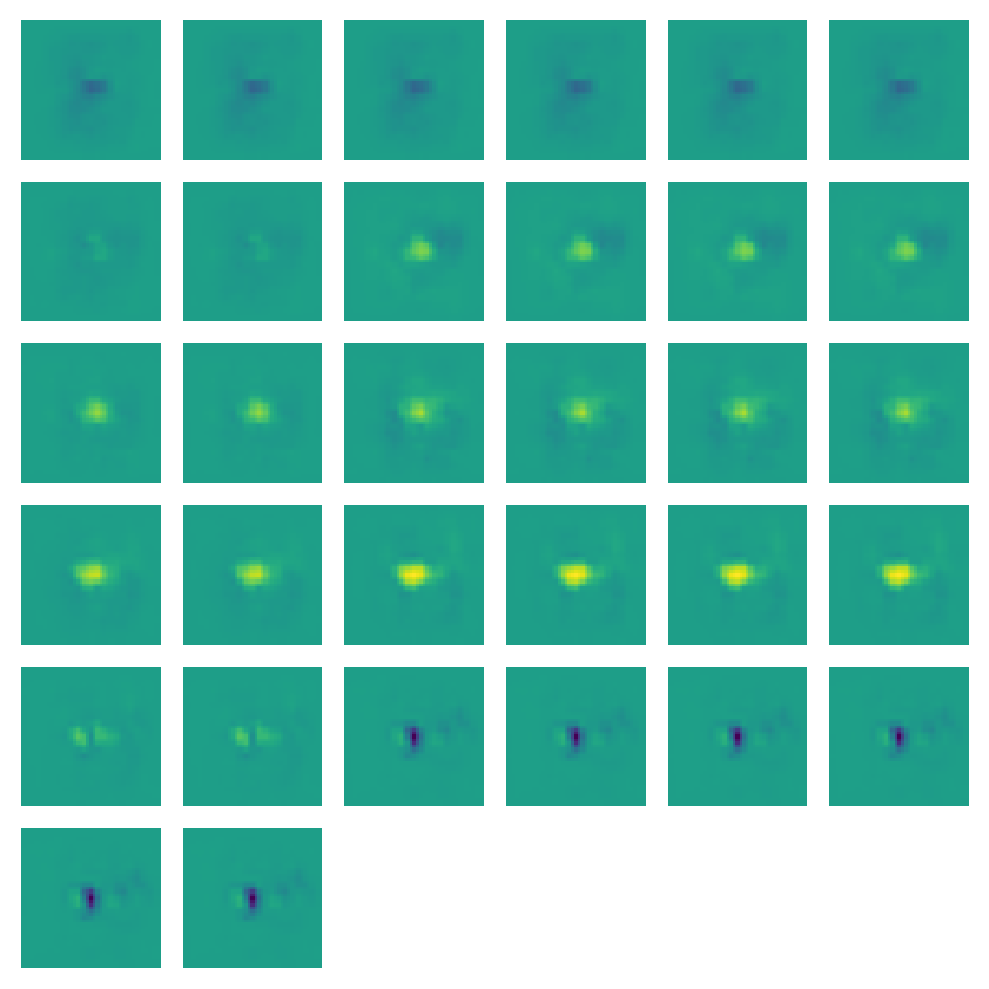

In [31]:
monai.visualize.matshow3d(volume=norm_heatmap, frame_dim=-1, channel_dim=1, every_n=1, margin=10, show=False)
plt.show()

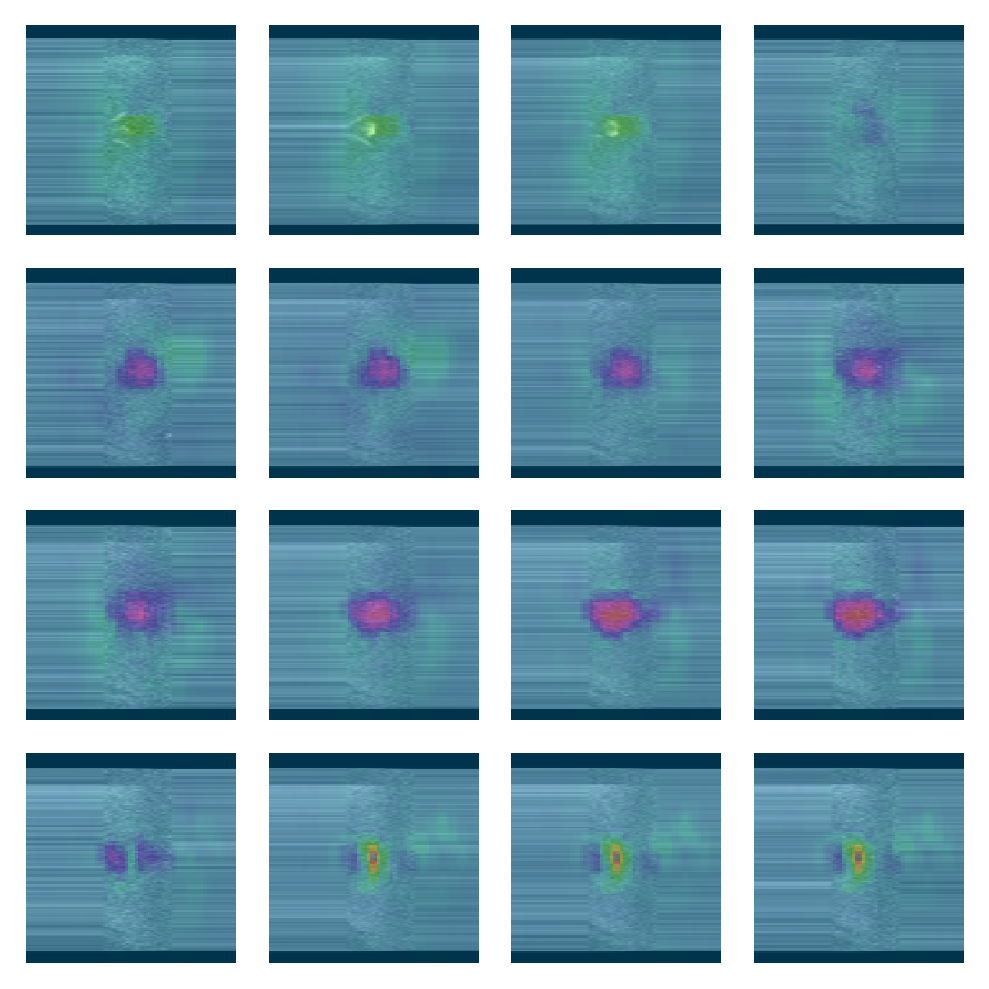

In [33]:
blended = monai.visualize.utils.blend_images(255*img.cpu()[1:2], 
                                                255*(norm_heatmap[0].cpu()), 
                                                alpha=0.3,
                                                transparent_background=True)
monai.visualize.matshow3d(volume=blended, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False)
plt.show()

# Gradcam + Guided BackPropagation

## Pretrained models 

[Ensamble] Idx 211 | True 1 | Pred 1 | Prob 0.5814


Computing GuidedBackpropSmoothGrad: 100%|██████████| 64/64 [00:09<00:00,  6.64it/s]


CAM shape: torch.Size([1, 128, 128, 32]), GBP shape: torch.Size([3, 128, 128, 32])


Computing GuidedBackpropSmoothGrad: 100%|██████████| 64/64 [00:09<00:00,  6.44it/s]


CAM shape: torch.Size([1, 128, 128, 32]), GBP shape: torch.Size([3, 128, 128, 32])


...

CAM shape: torch.Size([1, 128, 128, 32]), GBP shape: torch.Size([3, 128, 128, 32])


Computing GuidedBackpropSmoothGrad: 100%|██████████| 64/64 [00:09<00:00,  6.69it/s]


CAM shape: torch.Size([1, 128, 128, 32]), GBP shape: torch.Size([3, 128, 128, 32])


Computing GuidedBackpropSmoothGrad: 100%|██████████| 64/64 [00:09<00:00,  6.62it/s]


CAM shape: torch.Size([1, 128, 128, 32]), GBP shape: torch.Size([3, 128, 128, 32])


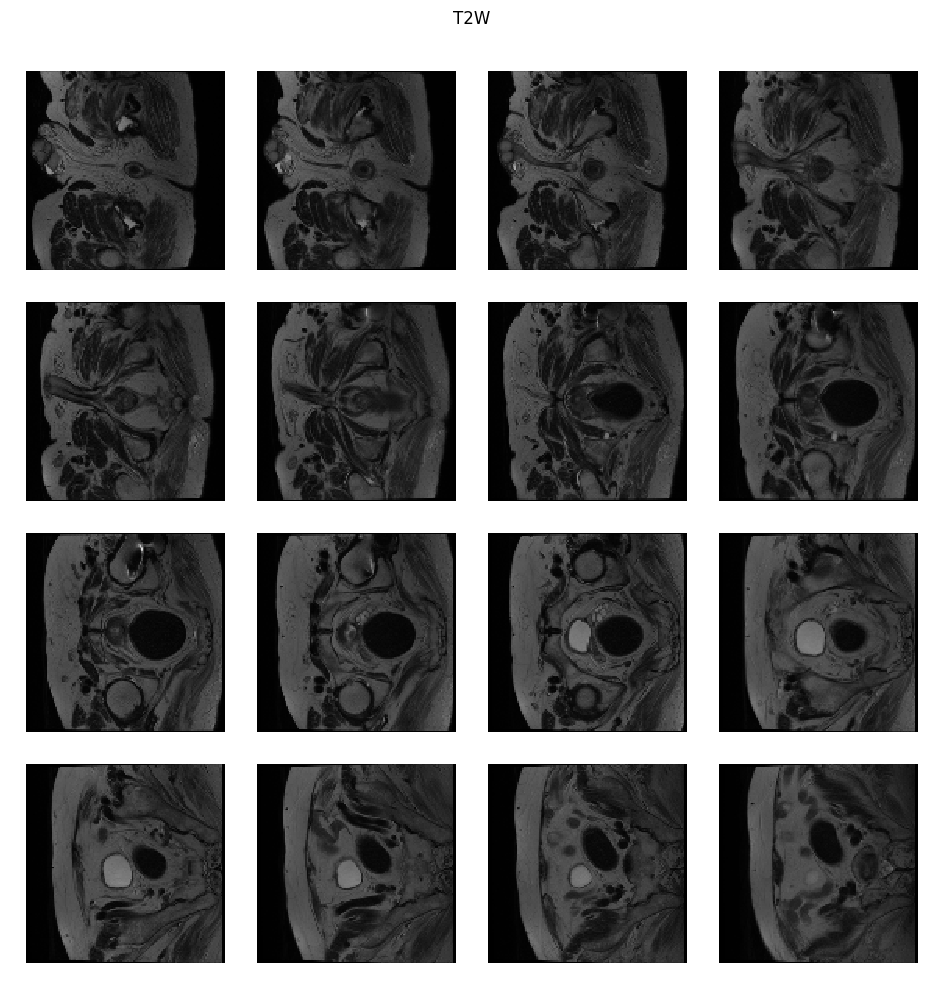

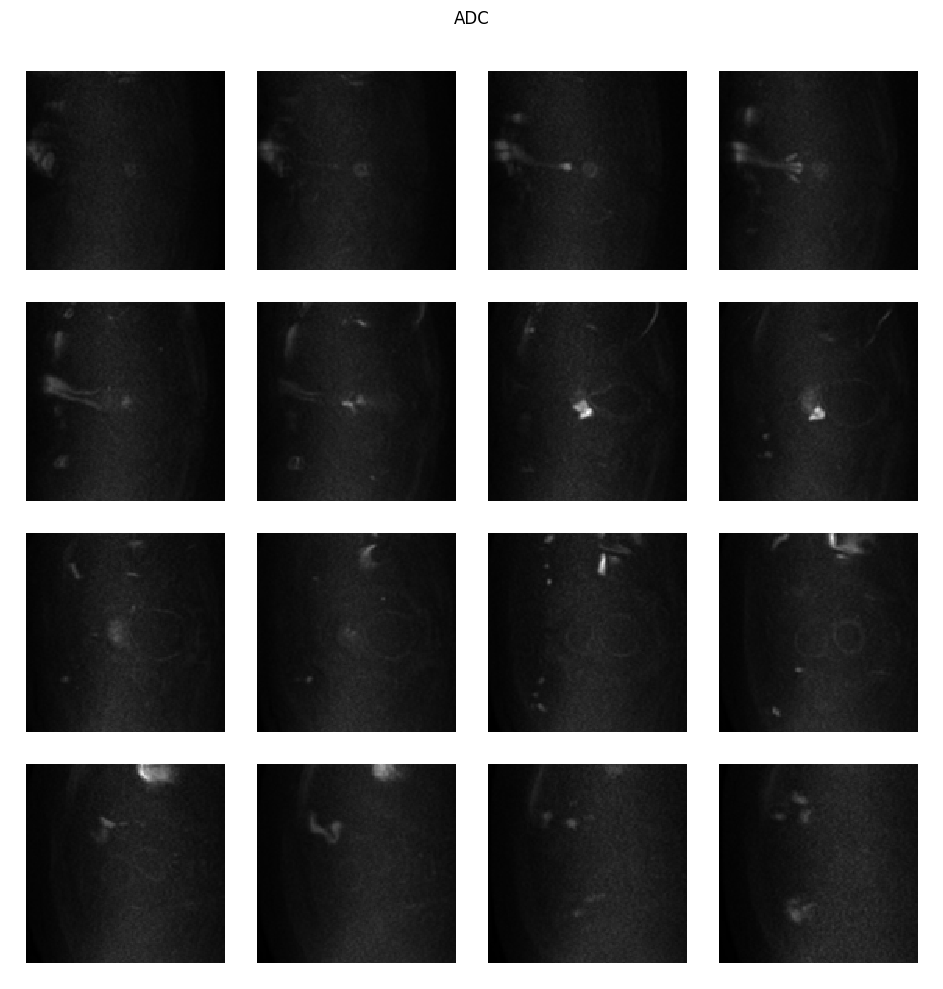

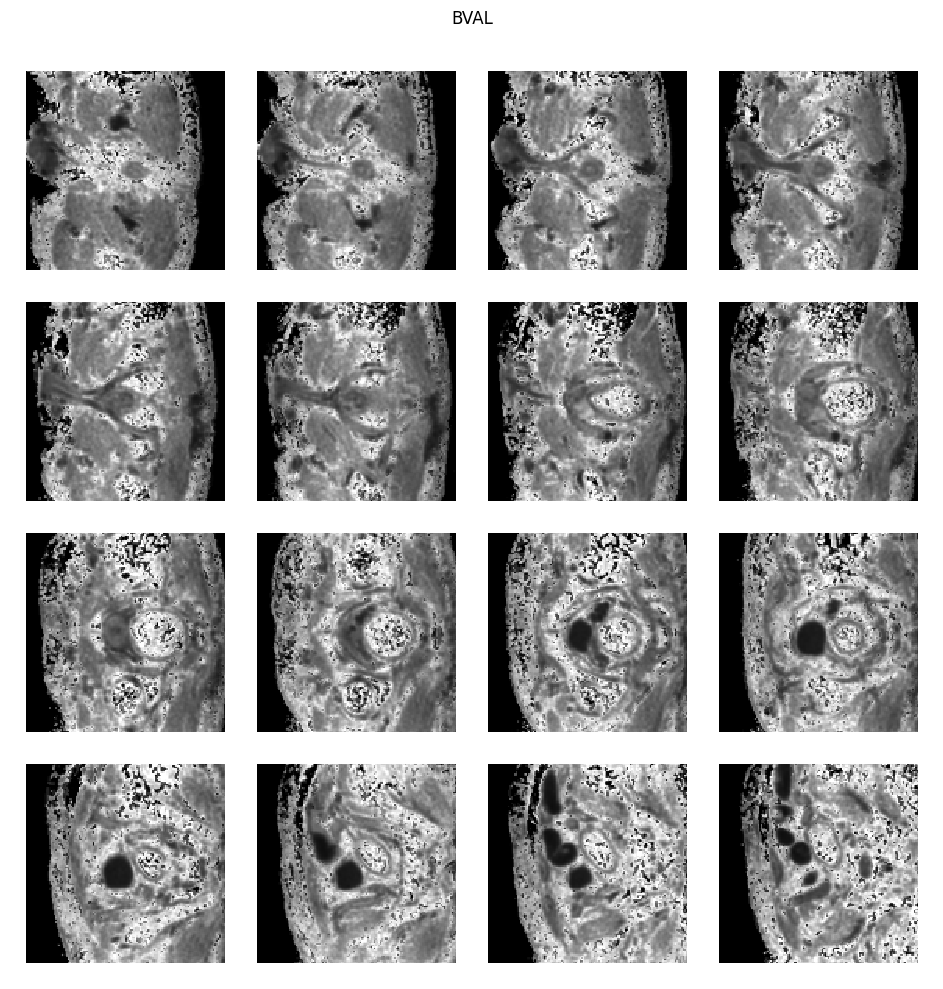

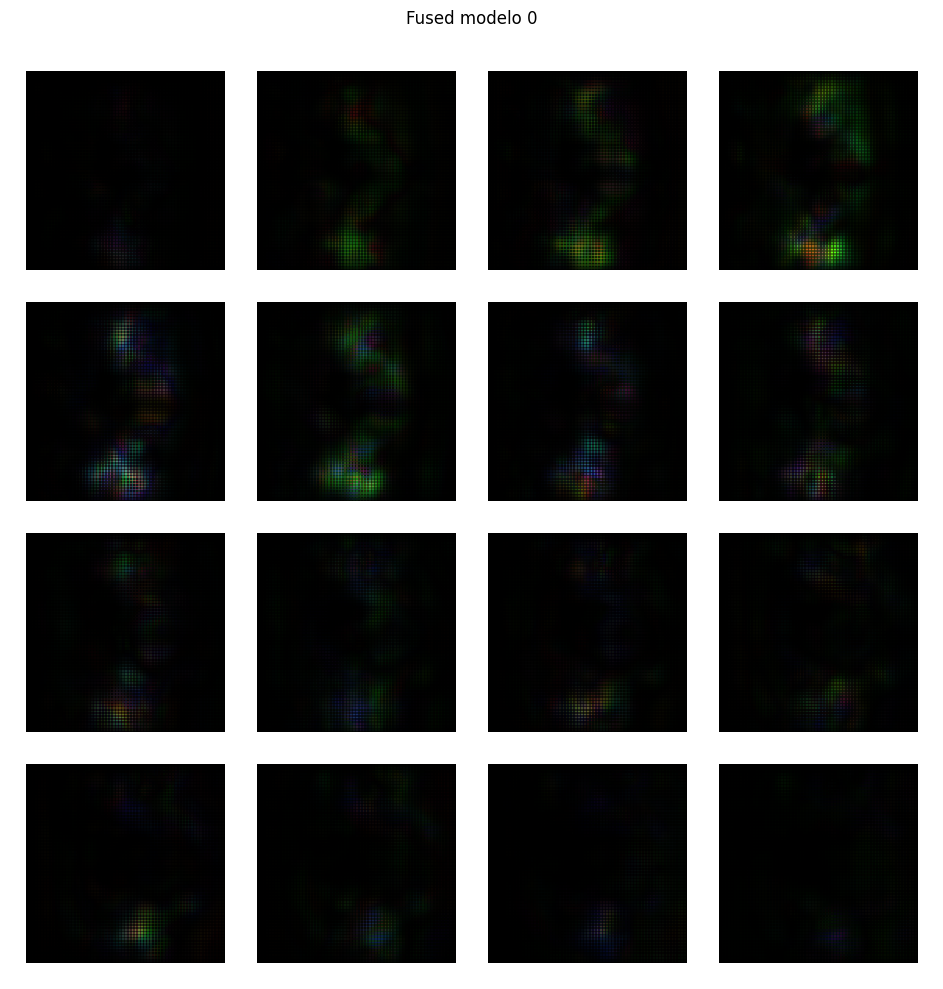

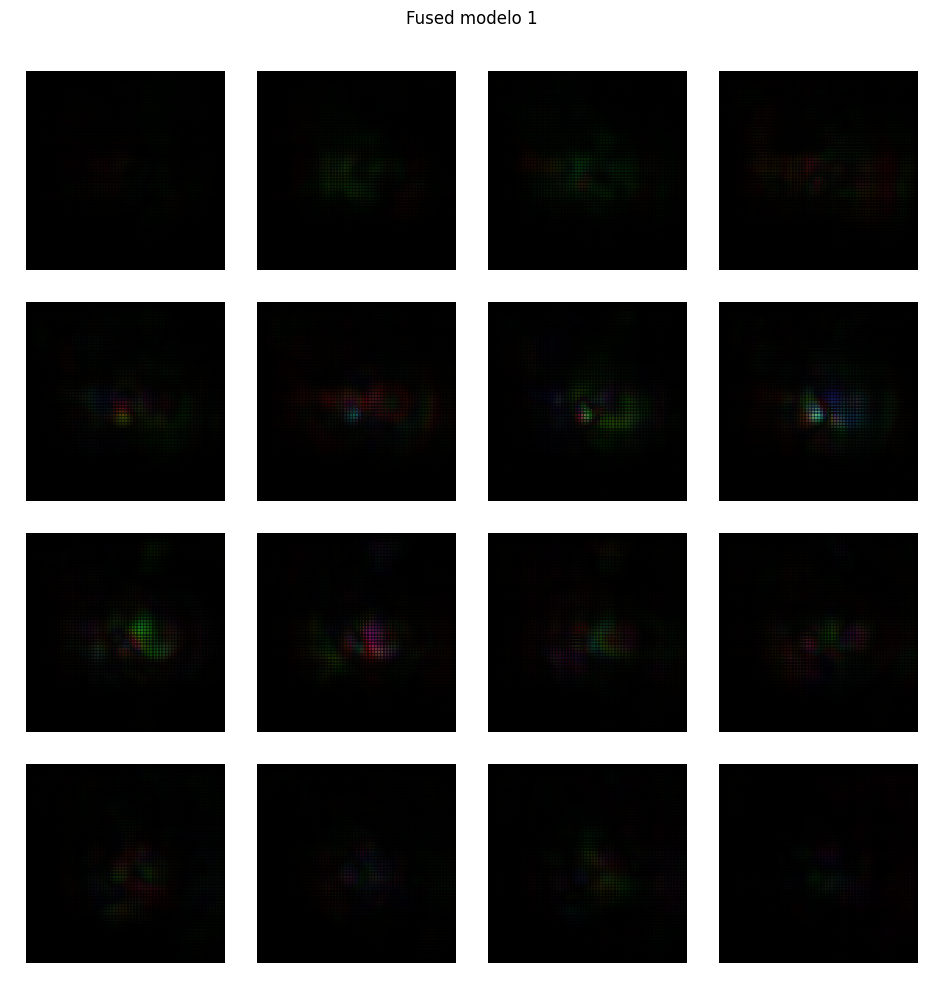

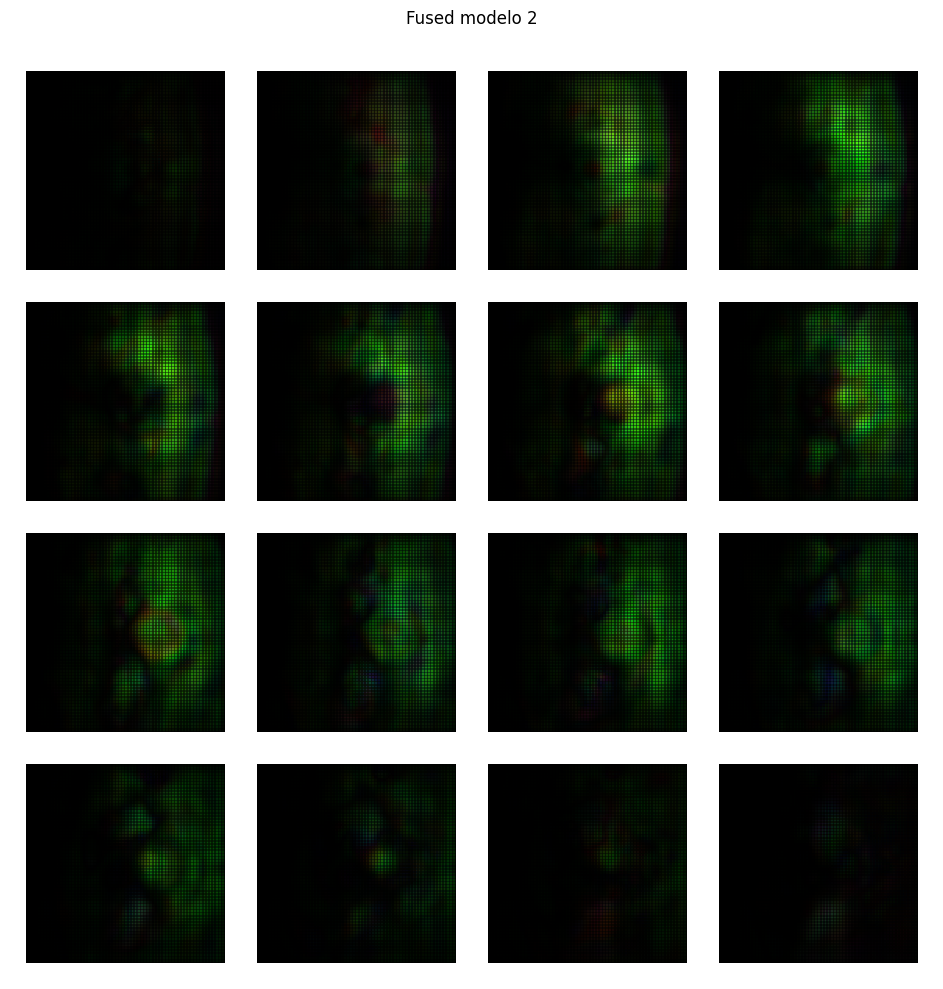

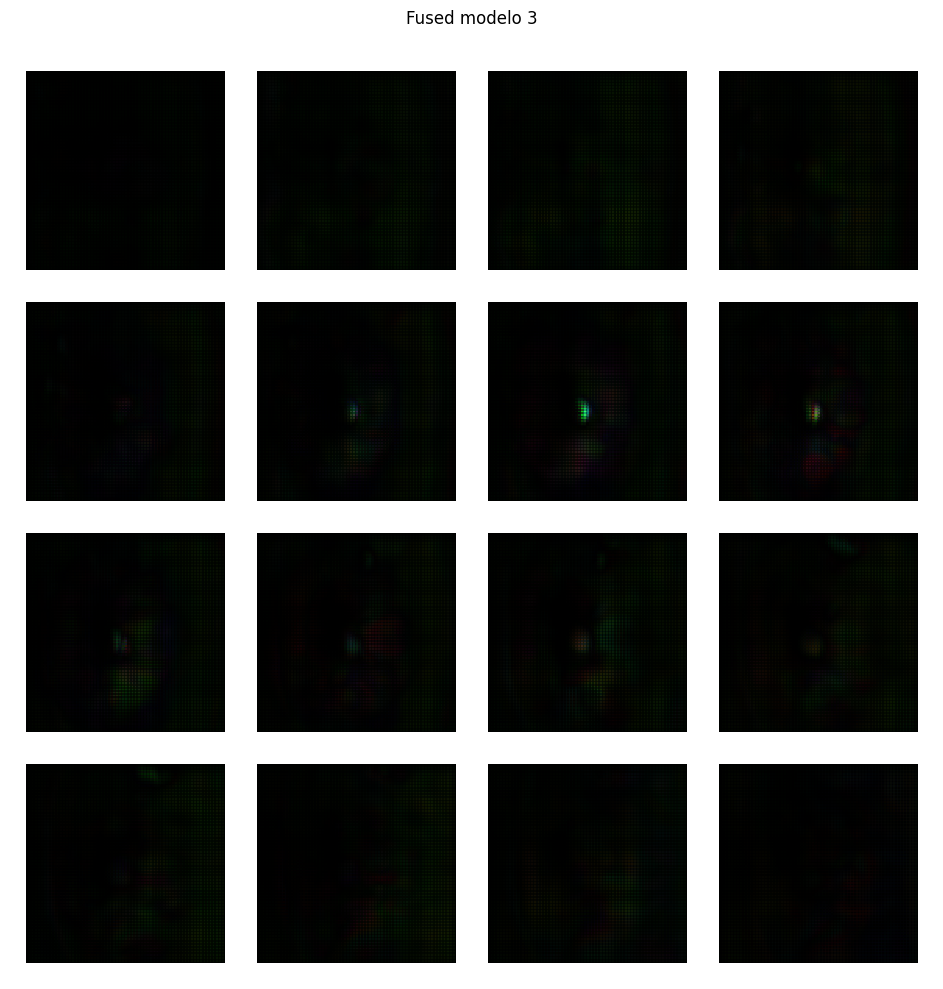

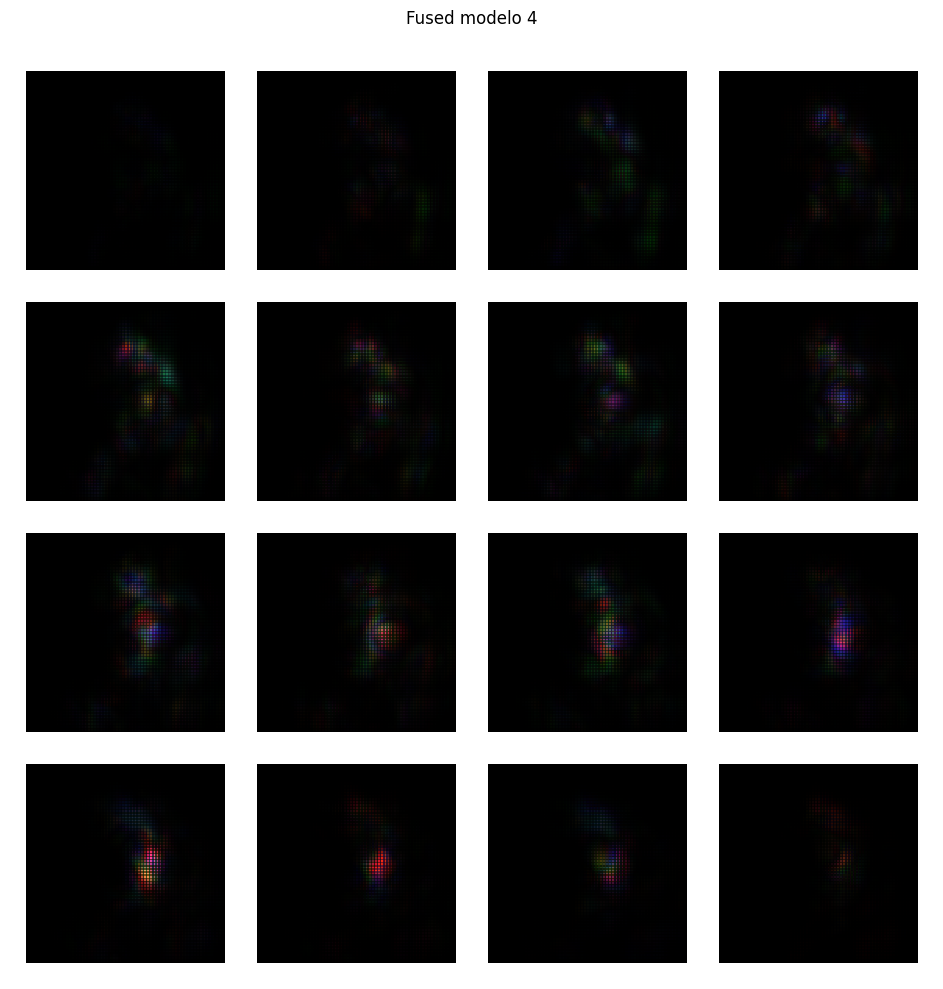

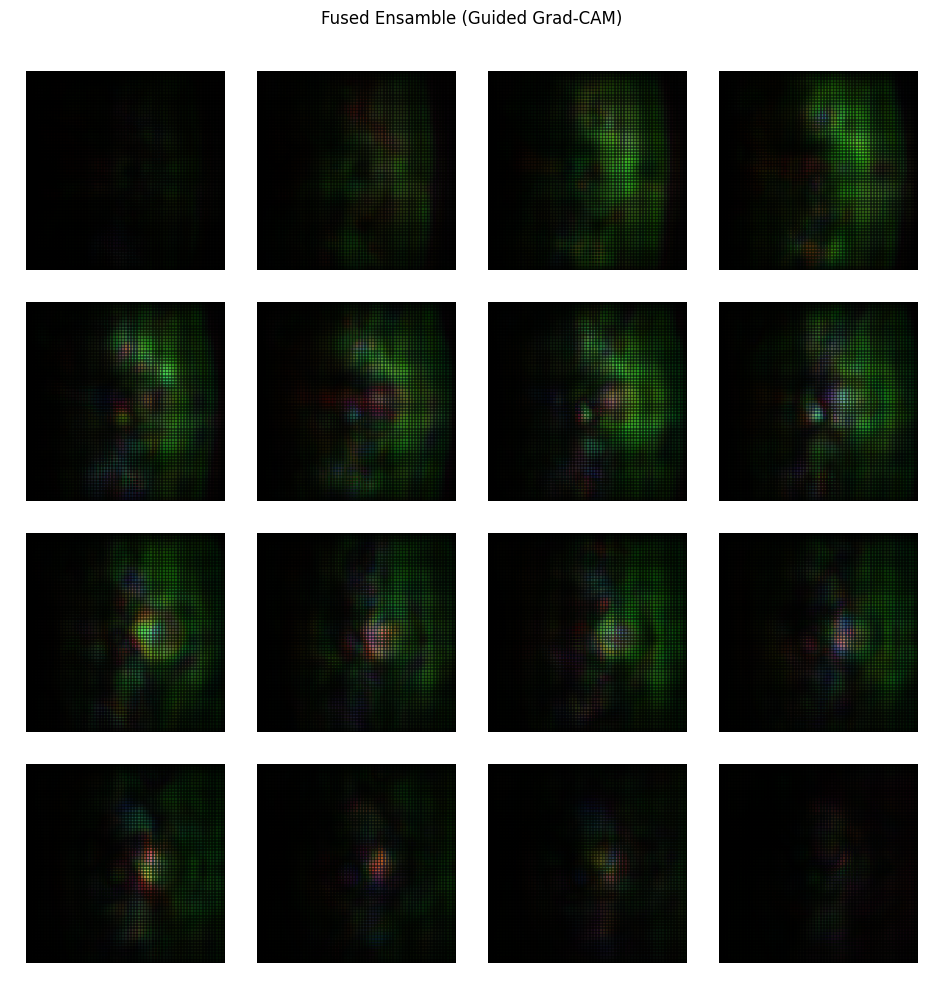

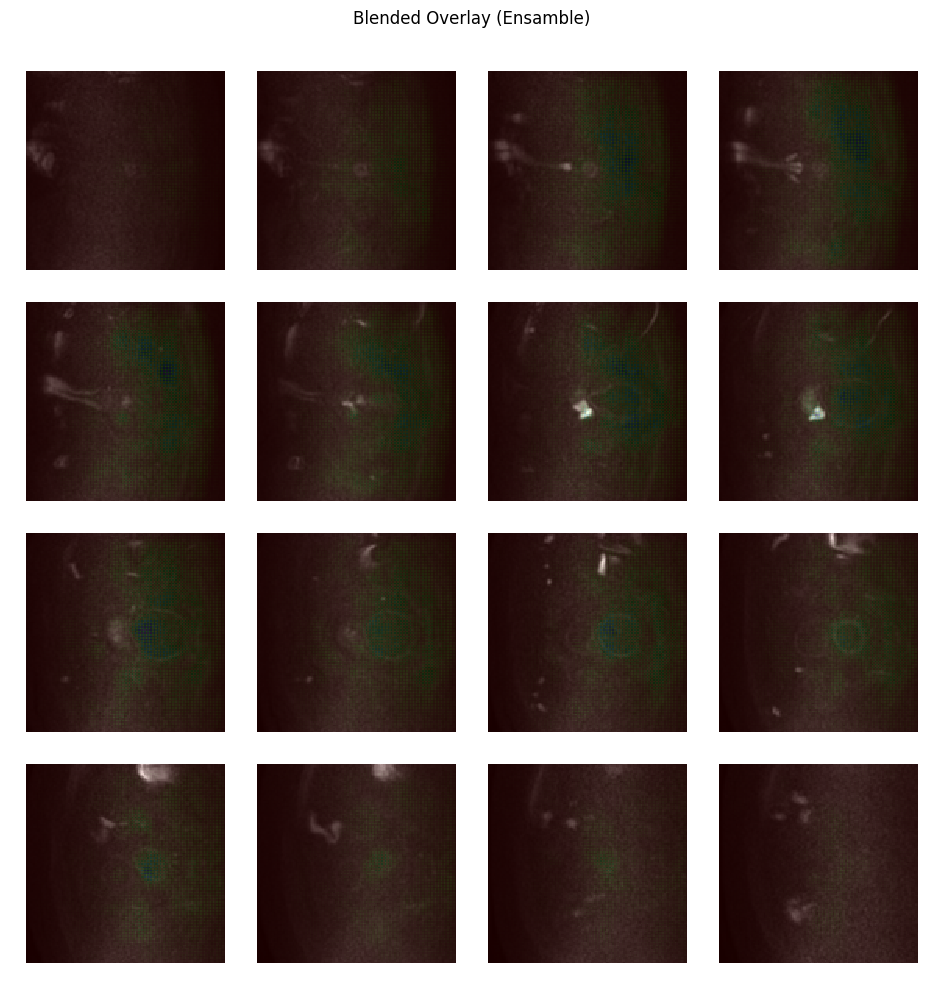

In [115]:
# === Ensamble Grad-CAM + GuidedBackprop (ponderado por confianza) ===
# Requiere: models_pretrained, no_pretrained_model, test_dataloader, device
#           EfficientNet_pretrained como en tu código, MONAI y torch importados.

import torch
import torch.nn.functional as F
import numpy as np
import monai
import matplotlib.pyplot as plt

# 1) Modelos del ensamble
all_models = models_pretrained  # ajusta si quieres solo 5

for m in all_models:
    m.eval().to(device)

# 2) Helpers CAM/GBP por modelo (cache)
cam_gbp_cache = []  # [(cam, gbp, model), ...]
for m in all_models:
    # Ajusta nombres de capas si tu wrapper cambia
    cam_obj = monai.visualize.class_activation_maps.CAM(
        nn_module=m,
        target_layers="model._conv_head",
        fc_layers="model._fc"
    )
    gbp_obj = monai.visualize.gradient_based.GuidedBackpropSmoothGrad(
        m,
        n_samples=64,
    )
    cam_gbp_cache.append((cam_obj, gbp_obj, m))

def _normalize(x):
    x = x - x.min()
    maxv = x.max()
    return x / maxv if maxv > 0 else x

# 3) Elegir muestra donde el ENSAMBLE acierta
max_tries = 15
for _ in range(max_tries):
    idx = np.random.randint(0, len(test_dataloader))
    sample = test_dataloader.dataset[idx]
    img = sample['image'].to(device)
    label_onehot = sample['label']
    true_label = int(label_onehot.argmax().item())

    with torch.no_grad():
        logits_list = [m(img.unsqueeze(0)) for m in all_models]
        probs_list = [F.softmax(l, dim=1) for l in logits_list]
        probs_stack = torch.stack(probs_list, dim=0)           # [M, 1, C]
        probs_mean = probs_stack.mean(dim=0)                   # [1, C]
        pred_label = int(probs_mean.argmax(dim=1).item())
        pred_conf = float(probs_mean[0, pred_label].item())

    if pred_label == true_label:
        break

print(f"[Ensamble] Idx {idx} | True {true_label} | Pred {pred_label} | Prob {pred_conf:.4f}")

# 4) Mapas por modelo y fusión por modelo
#    - Para clase predicha por el ensamble 'pred_label'
#    - Ponderar cada modelo por su prob. en esa clase
model_weights = []
per_model_fused = []  # lista de tensores [C,H,W] o [C,D,H,W]

for (cam_obj, gbp_obj, m), probs in zip(cam_gbp_cache, probs_list):
    m.zero_grad()
    with torch.enable_grad():
        x = img.unsqueeze(0).requires_grad_(True)

        # CAM puede aceptar "targets" si tu versión lo soporta; si no, usa el default
        cam_map = cam_obj(x=x).squeeze(0).detach().cpu()      # [C,...] o [1,...]
        gbp_map = gbp_obj(x=x).squeeze(0).detach().cpu()      # [C,...]

    cam_map = _normalize(cam_map)
    gbp_map = _normalize(gbp_map)

    # Alinear canales
    print(f"CAM shape: {cam_map.shape}, GBP shape: {gbp_map.shape}")
    if cam_map.dim() == gbp_map.dim() and cam_map.shape[0] == gbp_map.shape[0]:
        fused = _normalize(cam_map * gbp_map)
    else:
        # fallback: usa primer canal de CAM si es [1,...]
        fused = _normalize(cam_map[0:1] * gbp_map)

    per_model_fused.append(fused)
    model_weights.append(float(probs[0, pred_label].item()))

# 5) Agregación ponderada
#    Convertir a misma forma y hacer promedio ponderado
#    Usamos la forma del primero como referencia
ref = per_model_fused[0]
shape_ref = ref.shape
stacked = []
for f in per_model_fused:
    # si difiere en tamaño espacial, interpola
    if f.shape != shape_ref:
        # admite 3D o 2D; detecta dims
        if f.dim() == 3:  # [C,H,W]
            f = torch.nn.functional.interpolate(
                f.unsqueeze(0), size=shape_ref[-2:], mode='bilinear', align_corners=False
            ).squeeze(0)
        elif f.dim() == 4:  # [C,D,H,W] -> interpola H,W (y D si cambia)
            size_target = shape_ref[-3:]
            f = torch.nn.functional.interpolate(
                f.unsqueeze(0), size=size_target, mode='trilinear', align_corners=False
            ).squeeze(0)
    stacked.append(f.unsqueeze(0))  # [1,C,...]

stacked = torch.cat(stacked, dim=0)                    # [M,C,...]
w = torch.tensor(model_weights).view(-1, 1, *([1] * (stacked.dim()-2)))  # [M,1,1...]
w = w / (w.sum() + 1e-8)
fused_ensemble = _normalize((stacked * w).sum(dim=0))  # [C,...]

# 6) Selección de canal para mostrar (p.ej., ADC=1)
channel_to_show = 1 if fused_ensemble.shape[0] > 1 else 0

# 7) Preparar overlays
base_slice = 255 * img.detach().cpu()[channel_to_show:channel_to_show+1]
fused_255 = 255 * fused_ensemble[channel_to_show:channel_to_show+1]

blended = monai.visualize.utils.blend_images(
    base_slice, fused_255, alpha=0.1, transparent_background=True
)

# 8) Visualización
def show_volume(vol, title="", cmap=None):
    monai.visualize.matshow3d(
        volume=vol, frame_dim=-1, channel_dim=0, every_n=2, margin=10, show=False, cmap=cmap
    )
    plt.title(title)
    plt.show()

# Canales crudos
for c, name in enumerate(["T2W", "ADC", "BVAL"][:img.shape[0]]):
    show_volume(img.detach().cpu()[c:c+1], title=name, cmap="gray")

# Diagnósticos por modelo (opcional): descomenta si quieres verlos
for i, f in enumerate(per_model_fused):
    show_volume(f, title=f"Fused modelo {i}", cmap="gray")

# Ensamble final
show_volume(fused_ensemble, title="Fused Ensamble (Guided Grad-CAM)", cmap="gray")
show_volume(blended, title="Blended Overlay (Ensamble)", cmap=None)


Idx 58 | True 1 | Pred 1 | Prob 0.6985


Computing GuidedBackpropSmoothGrad: 100%|██████████| 32/32 [00:04<00:00,  6.99it/s]


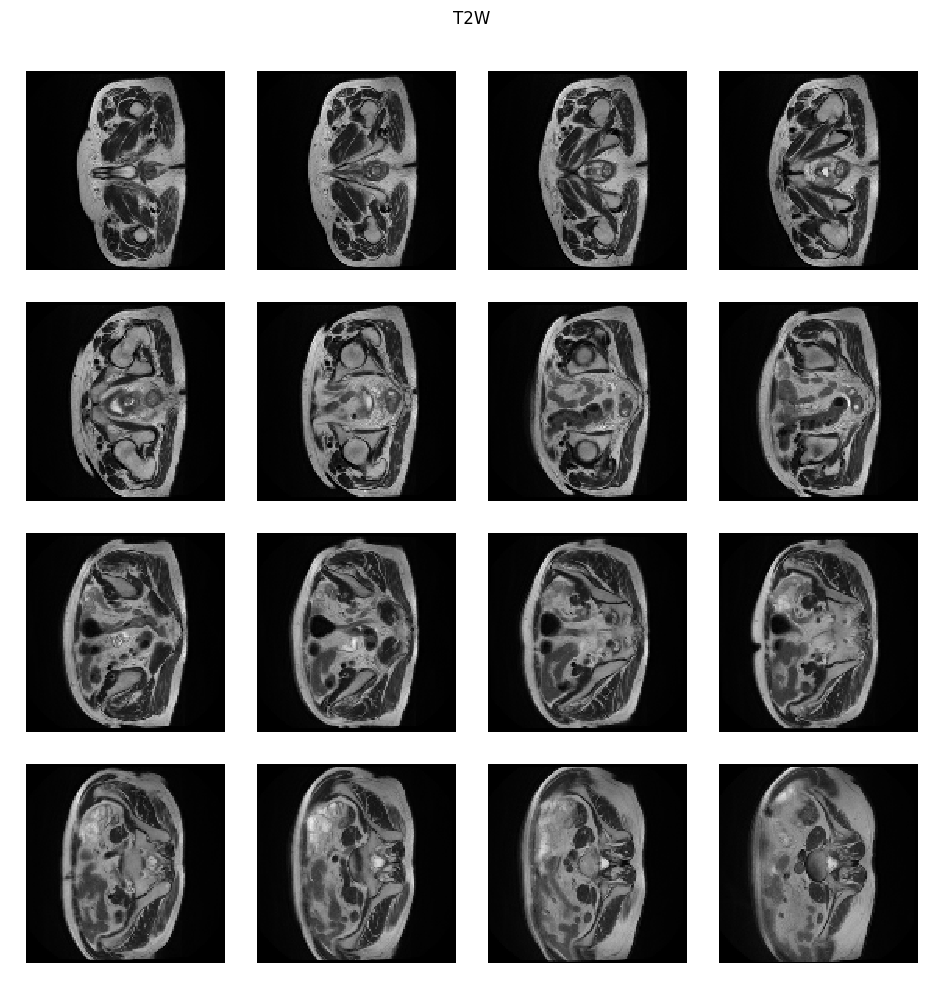

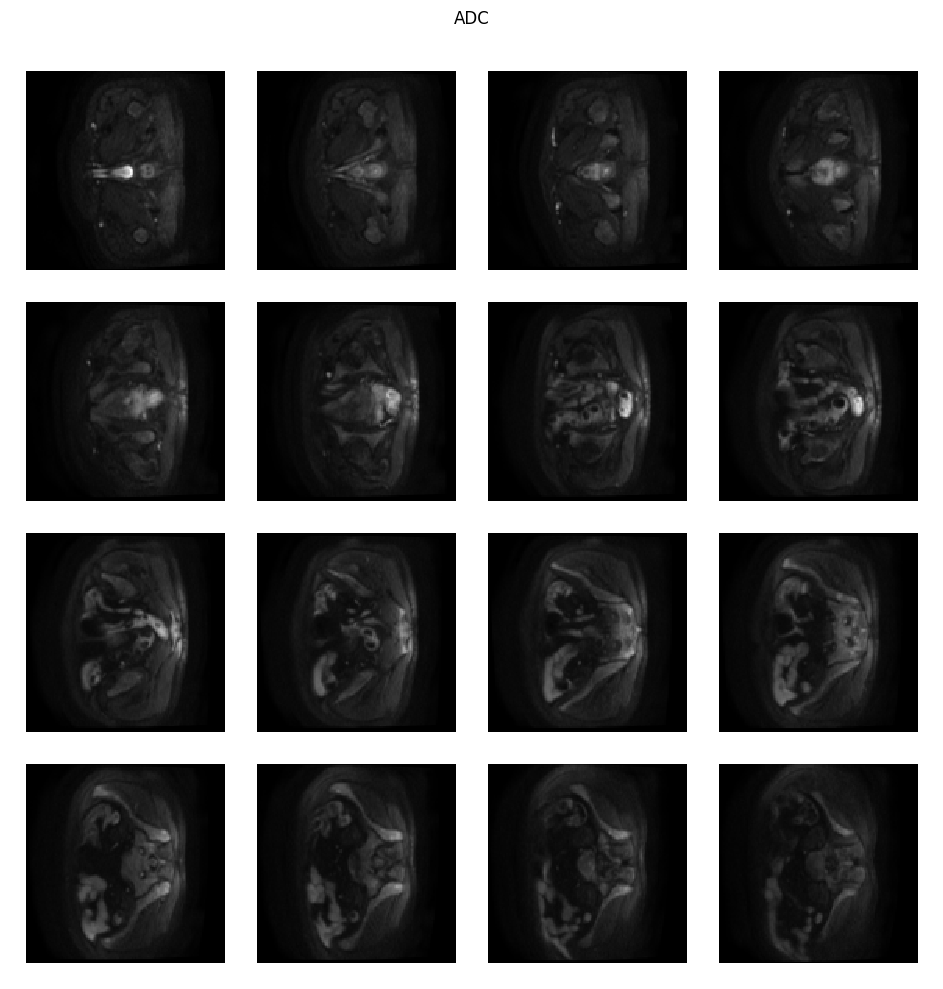

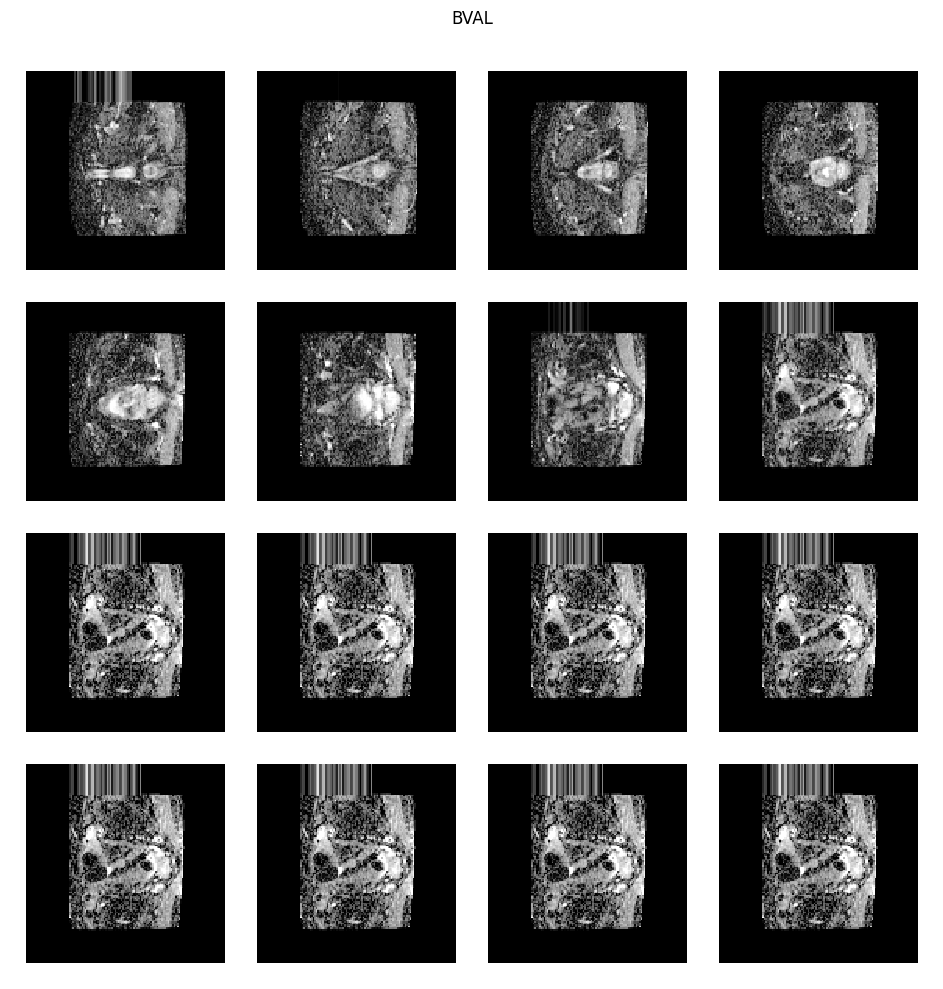

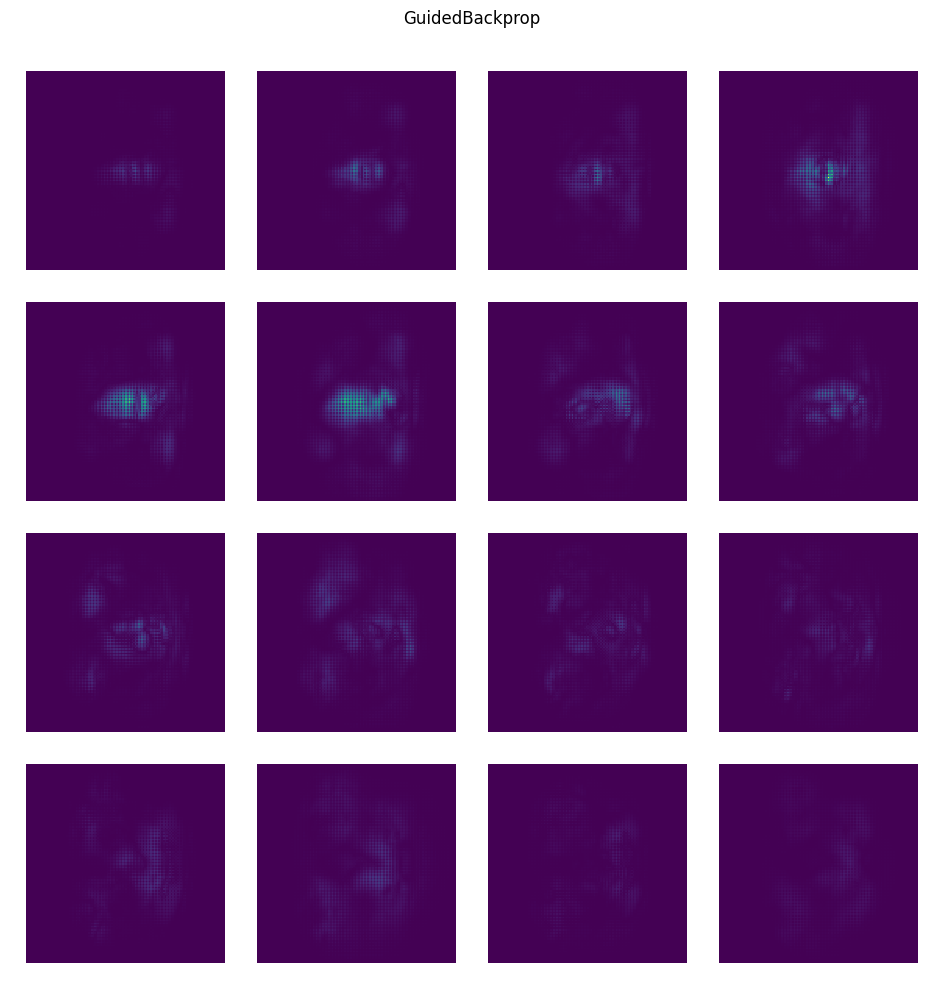

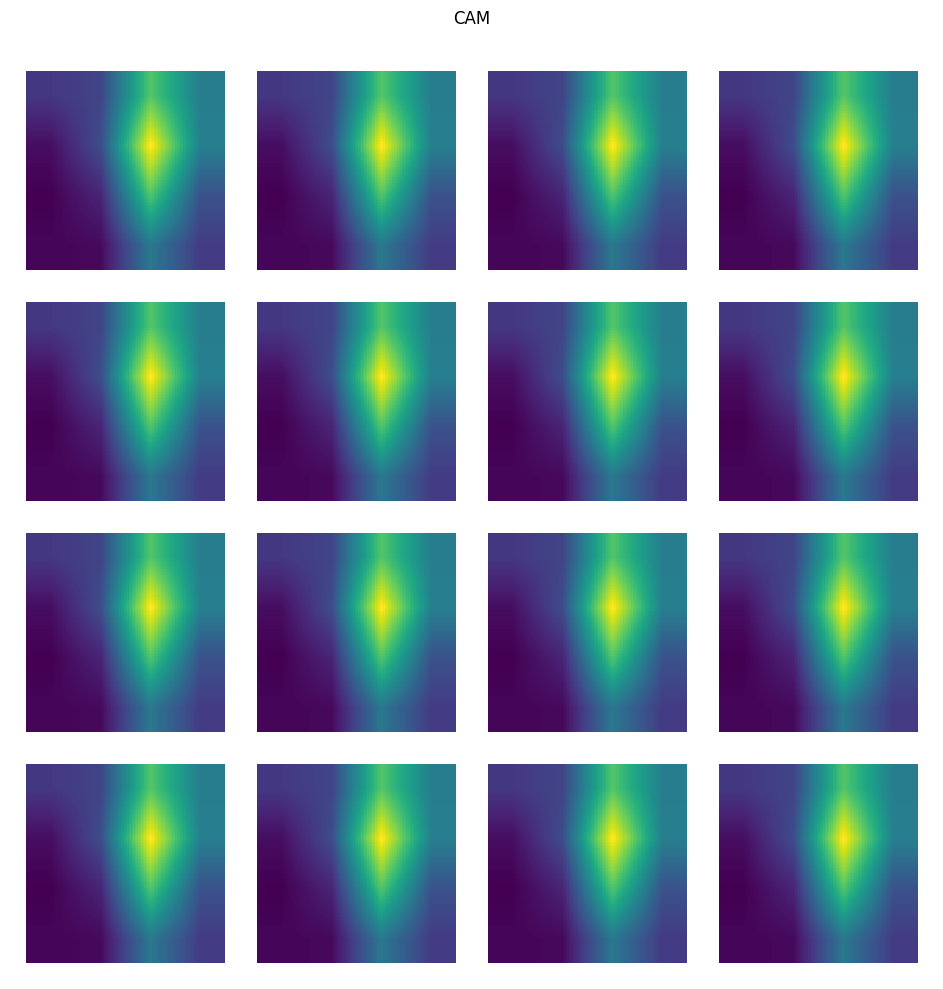

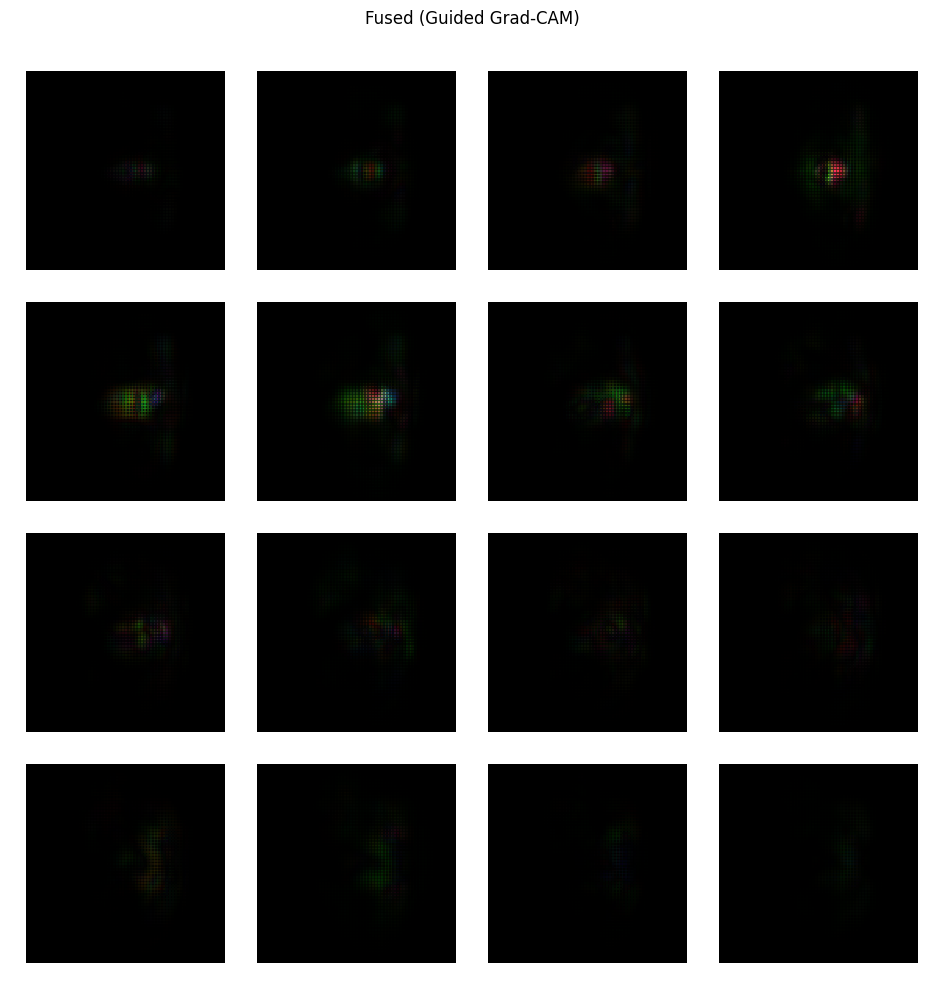

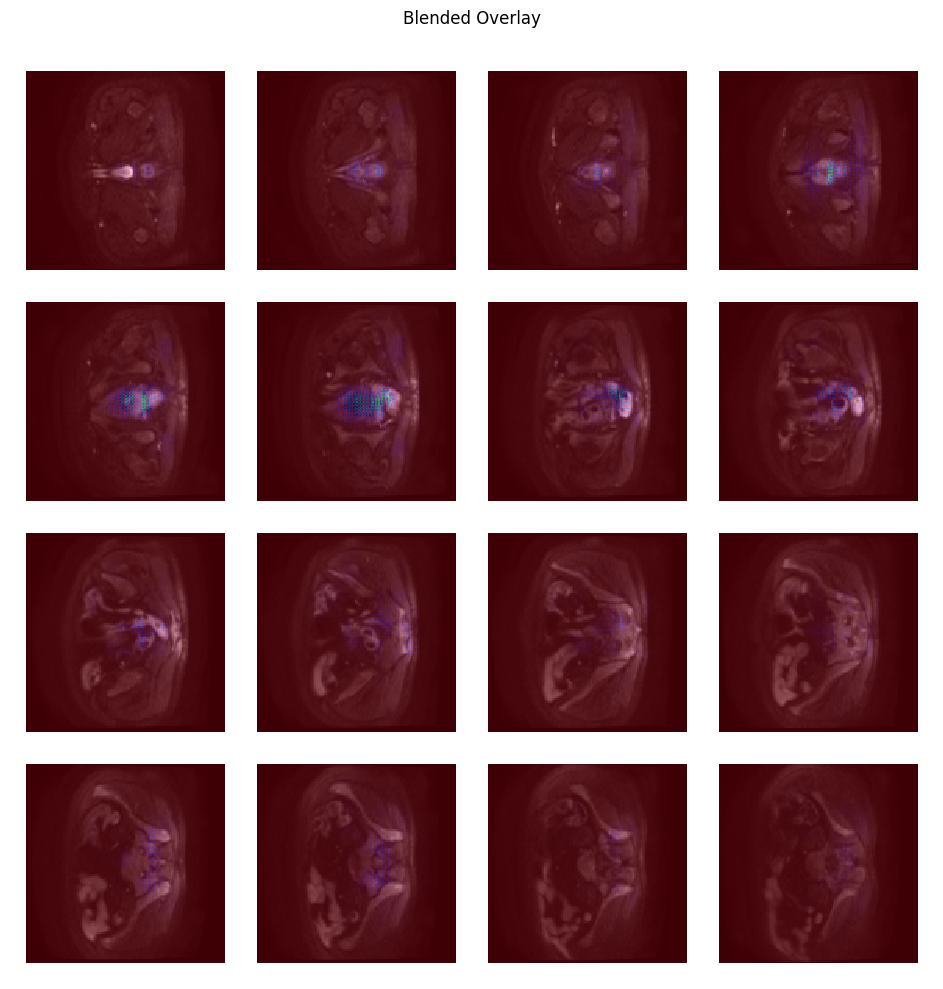

In [34]:
# Improved Grad-CAM + Guided Backprop (guided Grad-CAM style)
# Reuses existing: model, test_dataloader, device

model.eval()

# Create CAM / GBP objects once (recreate only if variables missing or model changed)
try:
    cam
except NameError:
    cam = monai.visualize.class_activation_maps.CAM(
        nn_module=model,
        target_layers="model._conv_head",
        fc_layers="model._fc"
    )
try:
    gbp
except NameError:
    gbp = monai.visualize.gradient_based.GuidedBackpropSmoothGrad(
        model,
        n_samples=32,
    )

def _normalize(x):
    x = x - x.min()
    maxv = x.max()
    return x / maxv if maxv > 0 else x

# Optionally loop until we pick a correctly classified sample
max_tries = 10
for _ in range(max_tries):
    idx = np.random.randint(0, len(test_dataloader))
    sample = test_dataloader.dataset[idx]
    img = sample['image'].to(device)
    label_onehot = sample['label']
    true_label = label_onehot.argmax().item()
    with torch.no_grad():
        probs = F.softmax(model(img.unsqueeze(0)), dim=1)
        pred_label = probs.argmax(dim=1).item()
    if pred_label == true_label:
        break

print(f"Idx {idx} | True {true_label} | Pred {pred_label} | Prob {probs[0, pred_label]:.4f}")

# Need gradients enabled (no torch.no_grad()) for GBP and CAM
model.zero_grad()

# Generate CAM & Guided Backprop
with torch.enable_grad():
    input_tensor = img.unsqueeze(0).requires_grad_(True)
    cam_map = cam(x=input_tensor).squeeze(0).detach().cpu()          # shape: (C, D, H, W) or (C, H, W)
    gbp_map = gbp(x=input_tensor).squeeze(0).detach().cpu()

# Normalize
cam_map = _normalize(cam_map)
gbp_map = _normalize(gbp_map)

# Guided Grad-CAM fusion (channel-wise multiply where applicable)
# If cam is single-channel per class, ensure dimensions align
if cam_map.shape[0] == gbp_map.shape[0]:
    fused = _normalize(cam_map * gbp_map)
else:
    # If CAM returns per-class map differently, fallback to broadcasting first channel
    fused = _normalize(cam_map[0:1] * gbp_map)

# Select channel 1 (ADC?) for visualization consistency with earlier cells
channel_to_show = 1 if gbp_map.shape[0] > 1 else 0

# Prepare overlays
base_slice = 255 * img.cpu()[channel_to_show:channel_to_show+1]
fused_255 = 255 * fused[channel_to_show:channel_to_show+1]

blended = monai.visualize.utils.blend_images(
    base_slice,
    -fused_255,
    alpha=0.25,
    transparent_background=True
)

# Visualization helpers
def show_volume(vol, title="", cmap=None):
    monai.visualize.matshow3d(
        volume=vol,
        frame_dim=-1,
        channel_dim=0,
        every_n=2,
        margin=10,
        show=False,
        cmap=cmap
    )
    plt.title(title)
    plt.show()

# Raw channels
for c, name in enumerate(["T2W", "ADC", "BVAL"][:img.shape[0]]):
    show_volume(img.cpu()[c:c+1], title=name, cmap="gray")

# GBP / CAM / Fused
show_volume(gbp_map[channel_to_show:channel_to_show+1], title="GuidedBackprop", cmap=None)
show_volume(cam_map if cam_map.ndim == 3 else cam_map[0:1], title="CAM", cmap=None)
show_volume(fused, title="Fused (Guided Grad-CAM)", cmap="gray")
show_volume(blended, title="Blended Overlay", cmap=None)

# Check dataset images

In [33]:
import pandas as pd

In [77]:
df = pd.read_csv('Files/data_with_splits_dep_disjoint.csv')
df_train = df[df['split'] == 'train']
df_val_test = df[(df['split'] == 'val') | (df['split'] == 'test')]

In [99]:
df_paper =  pd.read_excel('Files/Label_Paper.xlsx')

In [107]:
def drop_not_used_rows(row, df_paper):
    if row['split'] == 'train':
        return True
    if (row['subject'] in df_paper['label_MIDS_subject'].values and
        row['session'] in df_paper['label_MIDS_session'].values):
        return True
    return False

df_reports_val_true = df[df.apply(lambda row: drop_not_used_rows(row, df_paper), axis=1)]

    

In [109]:
df_reports_val_true.split.value_counts()

split
train    3675
val       414
Name: count, dtype: int64

In [110]:
df_reports_val_true.to_csv('Files/data_with_splits_dep_disjoint_val_test.csv', index=False)

In [78]:
df['split'] =  df['split'].apply(lambda x: 'val' if x == 'test' else x)
df.to_csv('Files/data_with_splits_dep_disjoint_val_test.csv', index=False)

In [101]:
df

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,split
0,sub-002726,ses-004030,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,75.0,NaN,NaN,NaN,6.70,NaN,2.0,0.0,1944-07-28,2020-05-02,train,False,NaN,val
1,sub-003019,ses-003234,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,70.0,NaN,NaN,NaN,19.50,NaN,5.0,0.0,1941-11-29,2012-01-31,train,False,NaN,val
2,sub-008321,ses-009264,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,69.0,NaN,NaN,NaN,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,val
3,sub-008321,ses-009264,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,69.0,NaN,NaN,NaN,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,val
4,sub-003327,ses-003551,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,57.0,NaN,NaN,NaN,12.60,NaN,3.0,0.0,1959-01-05,2016-12-05,train,False,NaN,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4655,sub-000098,ses-000098,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,50.0,NaN,NaN,NaN,NaN,77.2,5.0,1.0,1959-11-17,2010-10-09,val,True,65.647119,train
4656,sub-000095,ses-000095,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,71.0,NaN,NaN,NaN,NaN,65.0,NaN,0.0,1943-04-14,2014-12-09,val,True,62.103212,train
4657,sub-000116,ses-000116,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,82.0,NaN,NaN,NaN,40.57,NaN,5.0,1.0,1931-11-19,2014-07-28,val,True,37.088379,train
4658,sub-000116,ses-000116,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,82.0,NaN,NaN,NaN,40.57,NaN,5.0,1.0,1931-11-19,2014-07-28,val,True,37.088379,train


In [100]:
df_paper

,label_MIDS_session,label_MIDS_subject,project,Vínculo,URL,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,Used,MRI_Report,ID_XNAT_subject,ID_XNAT_session
0,ses-000079,sub-000079,p0042021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0042...,7,68,NaN,NaN,NaN,2.38,NaN,NaN,1,False,JUICIO JUICIO\nPaciente intervenido: PRadical ...,XNAT3_S36816,XNAT3_E91859
1,ses-000099,sub-000099,p0042021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0042...,7,57,NaN,NaN,NaN,5.900000000000000,NaN,"[4, 5]",1,False,DATOS CLÍNICOS: ADC prostata. Gleason 3+3 en ...,XNAT3_S36836,XNAT3_E91879
2,ses-000176,sub-000176,p0042021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0042...,17,64,NaN,0.0,NaN,10.08000000000000,56.5708,[4],1,False,MOTIVO MOTIVO MOTIVO PSA de 10 a 13. Biopsia n...,XNAT3_S36913,XNAT3_E91956
3,ses-005867,sub-005434,p0052021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0052...,21,77,NaN,NaN,NaN,NaN,NaN,NaN,1,False,"\n\n\n\n\n\nPACIENTE: <NAME> <NAME>, <NAME>\nP...",XNAT03_S00042,XNAT03_E00056
4,ses-006038,sub-005584,p0052021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0052...,5,63,NaN,NaN,NaN,8.960000000000001,27.0000,[4],1,False,\nINFORMACIÓN INFORMACIÓN\nPaciente con cáncer...,XNAT03_S00153,XNAT03_E00180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,ses-008199,sub-004469,p0052021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0052...,21,62,NaN,NaN,NaN,4.870000000000000,20.7948,NaN,1,False,"<NAME> <NAME>, <NAME> <NAME>\nPRESCRIPCION: D...",XNAT3_S41269,XNAT03_E05724
174,ses-004990,sub-004657,p0052021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0052...,7,80,NaN,1.0,NaN,0.5940000000000000,29.0000,[5],1,False,JUICIO JUICIO PSA de 8. Gleason 3+5 en 09/10 ...,XNAT3_S41458,XNAT3_E96801
175,ses-005111,sub-004771,p0052021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0052...,21,75,NaN,NaN,NaN,15.10000000000000,NaN,NaN,1,False,"\n\n\n\nPACIENTE: <NAME> <NAME>, <NAME>\nPRESC...",XNAT3_S41573,XNAT3_E96923
176,ses-005192,sub-004843,p0052021,CLICK ENLACE,https://ceib.cipf.es/xnat2/data/projects/p0052...,7,53,NaN,NaN,NaN,5.400000000000000,NaN,"[3, 1, 4, 4, 3, 4, 3, 1, 5]",1,False,DATOS CLÍNICOS: ADC de próstata bilateral Glea...,XNAT3_S41644,XNAT3_E97003


In [79]:
df

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,split
0,sub-002726,ses-004030,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,75.0,NaN,NaN,NaN,6.70,NaN,2.0,0.0,1944-07-28,2020-05-02,train,False,NaN,val
1,sub-003019,ses-003234,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,70.0,NaN,NaN,NaN,19.50,NaN,5.0,0.0,1941-11-29,2012-01-31,train,False,NaN,val
2,sub-008321,ses-009264,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,69.0,NaN,NaN,NaN,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,val
3,sub-008321,ses-009264,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,69.0,NaN,NaN,NaN,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,val
4,sub-003327,ses-003551,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,20.0,57.0,NaN,NaN,NaN,12.60,NaN,3.0,0.0,1959-01-05,2016-12-05,train,False,NaN,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4655,sub-000098,ses-000098,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,50.0,NaN,NaN,NaN,NaN,77.2,5.0,1.0,1959-11-17,2010-10-09,val,True,65.647119,train
4656,sub-000095,ses-000095,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,71.0,NaN,NaN,NaN,NaN,65.0,NaN,0.0,1943-04-14,2014-12-09,val,True,62.103212,train
4657,sub-000116,ses-000116,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,82.0,NaN,NaN,NaN,40.57,NaN,5.0,1.0,1931-11-19,2014-07-28,val,True,37.088379,train
4658,sub-000116,ses-000116,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,82.0,NaN,NaN,NaN,40.57,NaN,5.0,1.0,1931-11-19,2014-07-28,val,True,37.088379,train


In [38]:
df_val_test['subject'].nunique()

379

In [39]:
df_reports = pd.read_csv('Files/reports_complete_MIDS.csv')

In [40]:
df_reports

,label_MIDS_session,label_MIDS_subject,project,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,F_TACTO_RECTAL,F_PSA,F_csPC,VP_text,MRI_Report,reports_count
0,ses-000001,sub-000001,p0042021,7.0,77.0,NaN,1.0,NaN,5.040000000000000,48.472756,[5],1.0,1934-10-02,2012-07-04,NaN,-136.0,-115.0,"48,1 x 38,3 x 50,6 mm,",INFORMACION CLINICA:\nCáncer de próstata G 3+4...,1
1,ses-000002,sub-000002,p0042021,2.0,57.0,NaN,NaN,NaN,NaN,26.282880,NaN,0.0,1958-08-10,2015-10-18,NaN,NaN,-51.0,"medidas de 54 x 26 x 36 mm,",Exploración realizada:\nR M de próstata multip...,1
2,ses-000003,sub-000003,p0042021,7.0,69.0,NaN,2.0,NaN,2.320000000000000,NaN,NaN,1.0,1945-01-02,2014-03-07,NaN,-42.0,-18.0,NaN,JUICIO JUICIO Prostatectomía en Junio/2017. Pe...,1
3,ses-000004,sub-000004,p0042021,7.0,52.0,NaN,2.0,NaN,0.09800000000000000,NaN,NaN,1.0,1964-08-13,2017-03-24,NaN,-31.0,-63.0,NaN,JUICIO JUICIO Tras prostatectomía R1 en apex. ...,1
4,ses-000005,sub-000005,p0042021,7.0,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1944-02-16,2015-06-13,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10304,ses-005809,sub-005390,p0052021,17.0,73.0,NaN,1.0,NaN,0.3600000000000000,NaN,NaN,1.0,1939-06-23,2013-05-27,NaN,-21.0,55.0,NaN,MOTIVO MOTIVO MOTIVO Prostatectomía radical co...,1
10305,ses-005810,sub-005391,p0052021,5.0,62.0,NaN,NaN,NaN,7.960000000000000,83.865600,NaN,0.0,1952-01-11,2014-05-15,NaN,-168.0,-52.0,"64 x 56 x 45 mm,","TECNICA: Se practican planos axiales, sagitale...",1
10306,ses-005811,sub-005392,p0052021,5.0,71.0,NaN,NaN,NaN,6.290000000000000,NaN,NaN,0.0,1941-08-31,2012-10-24,NaN,-200.0,66.0,NaN,"TECNICA: Se practican planos axiales, sagitale...",1
10307,ses-005812,sub-005393,p0052021,4.0,54.0,NaN,NaN,NaN,NaN,62.287680,[3],0.0,1957-12-12,2011-12-13,NaN,NaN,476.0,Próstata de 62 x 46 x 42 mm de diámetro transv...,Paciente con elevación de PSA de forma persist...,1


In [41]:
df_reports_val = df_reports[df_reports['label_MIDS_subject'].isin(df_val_test['subject'].values)]

In [42]:
df_reports_val

,label_MIDS_session,label_MIDS_subject,project,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,F_TACTO_RECTAL,F_PSA,F_csPC,VP_text,MRI_Report,reports_count
64,ses-000065,sub-000065,p0042021,7.0,NaN,NaN,0.0,NaN,NaN,82.78452,[3],0.0,1942-04-11,NaN,NaN,NaN,687.0,5.7cm de eje transverso x 4.9cm de eje antero...,CLÍNICA : elevación mantenida del PSA con biop...,1
68,ses-000069,sub-000069,p0042021,7.0,62.0,NaN,0.0,NaN,13.01000000000000,134.18496,NaN,0.5,1948-05-27,2011-04-12,NaN,-50.0,-259.0,dimensiones máximas 6 cm de eje transverso x ...,JUICIO JUICIO psa 13\n\nTÉCNICA: RM prostática...,1
78,ses-000079,sub-000079,p0042021,7.0,68.0,NaN,NaN,NaN,2.38,NaN,NaN,1.0,1941-06-05,2010-05-03,NaN,-41.0,-43.0,NaN,JUICIO JUICIO\nPaciente intervenido: PRadical ...,1
98,ses-000099,sub-000099,p0042021,7.0,57.0,NaN,NaN,NaN,5.900000000000000,NaN,"[4, 5]",1.0,1950-03-28,2007-12-21,NaN,-157.0,70.0,NaN,DATOS CLÍNICOS: ADC prostata. Gleason 3+3 en ...,1
101,ses-000101,sub-000101,p0042021,7.0,62.0,NaN,1.0,NaN,7.600000000000000,70.00000,"[1, 1, 2, 4, 3]",0.0,1955-07-23,2018-06-19,NaN,-204.0,56.0,"58 x 41 x 57 mm (T, AP y CC)\nVolumen: 70 cc\n...","JUICIO JUICIO PSA 7,16. Primera BP negativa. M...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10110,ses-005613,sub-005217,p0052021,17.0,77.0,NaN,1.0,NaN,6.540000000000000,66.99264,NaN,0.0,1933-09-14,2011-02-19,NaN,-59.0,998.0,Próstata con unas dimensiones aproximadas de 4...,Motivo de consulta: neoplasia de próstata. Se ...,1
10142,ses-005648,sub-005246,p0052021,7.0,65.0,NaN,1.0,NaN,8.789999999999999,45.25000,[5],0.0,1949-05-14,2014-12-05,NaN,-103.0,7.0,"5.6 x 3.7 x 4.2cm (T, AP y CC)\nVolumen: 45...",JUICIO JUICIO Estadiaje local AC próstata\nTÉC...,1
10149,ses-005654,sub-005252,p0052021,7.0,62.0,NaN,1.0,NaN,11.10000000000000,24.40000,[4],0.0,1948-07-11,2010-12-17,NaN,-56.0,-399.0,"48 x 28 x 35 mm (T, AP y CC)\nVolumen: 24.4 cc...",JUICIO JUICIO CaP en seguimiento activo. RM an...,1
10237,ses-005742,sub-005332,p0052021,17.0,56.0,NaN,1.0,NaN,10.31000000000000,115.31520,NaN,0.0,1956-11-09,2013-04-19,NaN,-9.0,253.0,"Próstata de 6,6 x 6 x 5,6 cms de diámetros CC ...","MOTIVO MOTIVO MOTIVO PSA de 8,30. PSA libre d...",1


In [43]:
df_reports_val_true = df_reports_val[df_reports_val['csPC'] == 1]

In [44]:
df_reports_val_true

,label_MIDS_session,label_MIDS_subject,project,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,F_TACTO_RECTAL,F_PSA,F_csPC,VP_text,MRI_Report,reports_count
78,ses-000079,sub-000079,p0042021,7.0,68.0,NaN,NaN,NaN,2.38,NaN,NaN,1.0,1941-06-05,2010-05-03,NaN,-41.0,-43.0,NaN,JUICIO JUICIO\nPaciente intervenido: PRadical ...,1
98,ses-000099,sub-000099,p0042021,7.0,57.0,NaN,NaN,NaN,5.900000000000000,NaN,"[4, 5]",1.0,1950-03-28,2007-12-21,NaN,-157.0,70.0,NaN,DATOS CLÍNICOS: ADC prostata. Gleason 3+3 en ...,1
109,ses-000110,sub-000110,p0042021,7.0,68.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1949-05-23,2017-05-31,NaN,NaN,69.0,NaN,NaN,0
175,ses-000176,sub-000176,p0042021,17.0,64.0,NaN,0.0,NaN,10.08000000000000,56.5708,[4],1.0,1945-10-25,2010-09-11,NaN,-286.0,483.0,"Próstata de 4,6 x 5,5 x 4,3 cm de diámetros CC...",MOTIVO MOTIVO MOTIVO PSA de 10 a 13. Biopsia n...,1
233,ses-005867,sub-005434,p0052021,21.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1932-04-02,2010-03-14,NaN,NaN,17.0,NaN,"\n\n\n\n\n\nPACIENTE: <NAME> <NAME>, <NAME>\nP...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9578,ses-005083,sub-004746,p0052021,21.0,51.0,NaN,NaN,NaN,8.850000000000000,NaN,NaN,1.0,1963-01-21,2014-09-14,NaN,-112.0,-45.0,NaN,NaN,0
9604,ses-005111,sub-004771,p0052021,21.0,75.0,NaN,NaN,NaN,15.10000000000000,NaN,NaN,1.0,1933-06-19,2009-03-25,NaN,-138.0,-52.0,NaN,"\n\n\n\nPACIENTE: <NAME> <NAME>, <NAME>\nPRESC...",1
9666,ses-005175,sub-004827,p0052021,21.0,72.0,NaN,NaN,NaN,77.70000000000000,NaN,NaN,1.0,1941-10-23,2014-04-13,NaN,-164.0,-89.0,NaN,NaN,0
9687,ses-005192,sub-004843,p0052021,7.0,53.0,NaN,NaN,NaN,5.400000000000000,NaN,"[3, 1, 4, 4, 3, 4, 3, 1, 5]",1.0,1957-02-28,2011-01-16,NaN,-118.0,96.0,NaN,DATOS CLÍNICOS: ADC de próstata bilateral Glea...,1


In [45]:
df_MIDS_XNAT = pd.read_csv('Files/variablesPT4_deps_ready_final_new_MIDS.tsv', sep='\t')

df_MIDS_XNAT['label_XNAT_session'] = df_MIDS_XNAT['label_XNAT_session'].fillna(0)
df_MIDS_XNAT['label_MIDS_session'] = df_MIDS_XNAT['label_XNAT_session'].astype(int).astype(str).str.zfill(6)
df_MIDS_XNAT['label_MIDS_session'] = df_MIDS_XNAT['label_MIDS_session'].apply(lambda x: 'ses-'+x)

df_MIDS_XNAT['label_XNAT_subject'] = df_MIDS_XNAT['label_XNAT_subject'].fillna(0)
df_MIDS_XNAT['label_MIDS_subject'] = df_MIDS_XNAT['label_XNAT_subject'].astype(int).astype(str).str.zfill(6)
df_MIDS_XNAT['label_MIDS_subject'] = df_MIDS_XNAT['label_MIDS_subject'].apply(lambda x: 'sub-'+x)

df_MIDS_XNAT = df_MIDS_XNAT[['label_MIDS_subject', 'label_MIDS_session', 'ID_XNAT_subject','ID_XNAT_session']]

In [46]:
df_MIDS_XNAT

,label_MIDS_subject,label_MIDS_session,ID_XNAT_subject,ID_XNAT_session
0,sub-000001,ses-000001,XNAT3_S36738,XNAT3_E91781
1,sub-000002,ses-000002,XNAT3_S36739,XNAT3_E91782
2,sub-000003,ses-000003,XNAT3_S36740,XNAT3_E91783
3,sub-000004,ses-000004,XNAT3_S36741,XNAT3_E91784
4,sub-000005,ses-000005,XNAT3_S36742,XNAT3_E91785
...,...,...,...,...
10304,sub-005390,ses-005809,XNAT3_S42195,XNAT3_E97620
10305,sub-005391,ses-005810,XNAT3_S42196,XNAT3_E97621
10306,sub-005392,ses-005811,XNAT3_S42197,XNAT3_E97622
10307,sub-005393,ses-005812,XNAT3_S42198,XNAT3_E97623


In [47]:
df_reports_val_true = df_reports_val_true.merge(df_MIDS_XNAT, on=['label_MIDS_subject', 'label_MIDS_session'], how='left')

In [48]:
df_reports_val_true

,label_MIDS_session,label_MIDS_subject,project,dep,ED,AF,TB,TR,PSA,VP,...,F_nacimiento,F_RM,F_TACTO_RECTAL,F_PSA,F_csPC,VP_text,MRI_Report,reports_count,ID_XNAT_subject,ID_XNAT_session
0,ses-000079,sub-000079,p0042021,7.0,68.0,NaN,NaN,NaN,2.38,NaN,...,1941-06-05,2010-05-03,NaN,-41.0,-43.0,NaN,JUICIO JUICIO\nPaciente intervenido: PRadical ...,1,XNAT3_S36816,XNAT3_E91859
1,ses-000099,sub-000099,p0042021,7.0,57.0,NaN,NaN,NaN,5.900000000000000,NaN,...,1950-03-28,2007-12-21,NaN,-157.0,70.0,NaN,DATOS CLÍNICOS: ADC prostata. Gleason 3+3 en ...,1,XNAT3_S36836,XNAT3_E91879
2,ses-000110,sub-000110,p0042021,7.0,68.0,NaN,NaN,NaN,NaN,NaN,...,1949-05-23,2017-05-31,NaN,NaN,69.0,NaN,NaN,0,XNAT3_S36847,XNAT3_E91890
3,ses-000176,sub-000176,p0042021,17.0,64.0,NaN,0.0,NaN,10.08000000000000,56.5708,...,1945-10-25,2010-09-11,NaN,-286.0,483.0,"Próstata de 4,6 x 5,5 x 4,3 cm de diámetros CC...",MOTIVO MOTIVO MOTIVO PSA de 10 a 13. Biopsia n...,1,XNAT3_S36913,XNAT3_E91956
4,ses-005867,sub-005434,p0052021,21.0,77.0,NaN,NaN,NaN,NaN,NaN,...,1932-04-02,2010-03-14,NaN,NaN,17.0,NaN,"\n\n\n\n\n\nPACIENTE: <NAME> <NAME>, <NAME>\nP...",2,XNAT03_S00042,XNAT03_E00056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,ses-005083,sub-004746,p0052021,21.0,51.0,NaN,NaN,NaN,8.850000000000000,NaN,...,1963-01-21,2014-09-14,NaN,-112.0,-45.0,NaN,NaN,0,XNAT3_S41547,XNAT3_E96894
227,ses-005111,sub-004771,p0052021,21.0,75.0,NaN,NaN,NaN,15.10000000000000,NaN,...,1933-06-19,2009-03-25,NaN,-138.0,-52.0,NaN,"\n\n\n\nPACIENTE: <NAME> <NAME>, <NAME>\nPRESC...",1,XNAT3_S41573,XNAT3_E96923
228,ses-005175,sub-004827,p0052021,21.0,72.0,NaN,NaN,NaN,77.70000000000000,NaN,...,1941-10-23,2014-04-13,NaN,-164.0,-89.0,NaN,NaN,0,XNAT3_S41628,XNAT3_E96986
229,ses-005192,sub-004843,p0052021,7.0,53.0,NaN,NaN,NaN,5.400000000000000,NaN,...,1957-02-28,2011-01-16,NaN,-118.0,96.0,NaN,DATOS CLÍNICOS: ADC de próstata bilateral Glea...,1,XNAT3_S41644,XNAT3_E97003


In [49]:
df_reports_val_true.to_csv('Files/reports_val_test_csPC.csv', index=False)